In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("..") / ".env", override=True)

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID", "")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY", "")
os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("S3_ENDPOINT", "")
os.environ["AWS_REQUEST_CHECKSUM_CALCULATION"] = "when_required"
os.environ["AWS_RESPONSE_CHECKSUM_VALIDATION"] = "when_required"

In [2]:
import numpy as np
import pandas as pd
# import mlflow
import joblib

# 1. Configure MLflow
# mlflow.enable_system_metrics_logging()
# mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URL", "http://localhost:5000"))
# mlflow.set_experiment("Greenhouse_Irrigation_Prediction")

# 2. Enable Autologging
# mlflow.sklearn.autolog()


In [3]:
df = pd.read_csv("../01_dataset/cropdata.csv")
df.head()


,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [4]:
df.shape


(16411, 7)

In [5]:
df.dtypes


crop ID            object
soil_type          object
Seedling Stage     object
MOI                 int64
temp                int64
humidity          float64
result              int64
dtype: object

In [6]:
obj_cols = df.select_dtypes(include=["object"]).columns
for col in obj_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: crop ID
crop ID
Wheat     6213
Chilli    2764
Potato    2504
Carrot    2475
Tomato    2455
Name: count, dtype: int64

Column: soil_type
soil_type
Clay Soil        3726
Sandy Soil       3678
Red Soil         2763
Loam Soil        2376
Black Soil       1929
Alluvial Soil    1243
Chalky Soil       696
Name: count, dtype: int64

Column: Seedling Stage
Seedling Stage
Flowering                                        3002
Seedling Stage                                   2931
Vegetative Growth / Root or Tuber Development    2902
Germination                                      2895
Pollination                                      2196
Fruit/Grain/Bulb Formation                        845
Maturation                                        845
Harvest                                           795
Name: count, dtype: int64


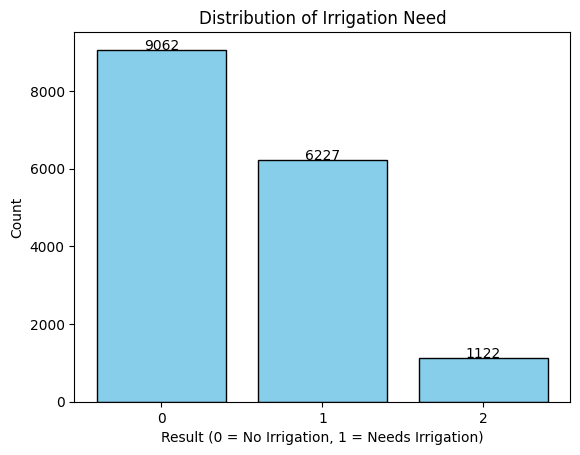

In [7]:
import matplotlib.pyplot as plt

counts = df["result"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values, color="skyblue", edgecolor="black")
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.2, str(v), ha="center", fontsize=10)

plt.xlabel("Result (0 = No Irrigation, 1 = Needs Irrigation)")
plt.ylabel("Count")
plt.title("Distribution of Irrigation Need")
plt.show()


In [8]:
cat_cols = ["crop ID", "soil_type", "Seedling Stage"]
num_cols = ["MOI", "temp", "humidity"]

X = df[cat_cols + num_cols]
y = df["result"]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
print(y_train.unique())
print(y_test.unique())
print(sorted(y.unique()))

[1 2 0]
[1 0 2]
[np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=10000, random_state=0)),
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred, average="weighted")

# mlflow.sklearn.autolog() logs the full pipeline automatically
print(f"Logistic Regression model accuracy: {acc:.2f}%")
print(f"F1 Score: {f1:.2f}")

model_path = "../04_starter-kit/model.joblib"
joblib.dump(model, model_path)
print(f"Model saved locally to: {model_path}")

# Sanity check: raw dict rows (same shape as Vayu Model Serving /predict)
sample = pd.DataFrame(
    [
        {
            "crop ID": "Wheat",
            "soil_type": "Black Soil",
            "Seedling Stage": "Germination",
            "MOI": 1,
            "temp": 25,
            "humidity": 80.0,
        }
    ]
)
print(f"Sample serving-style prediction: {model.predict(sample)[0]}")

Logistic Regression model accuracy: 82.70%
F1 Score: 0.80
Model saved locally to: ../04_starter-kit/model.joblib
Sample serving-style prediction: 1


In [12]:
f1_score(y_test, y_pred, average="weighted")


0.8015739303273981

In [13]:
# mlflow.end_run()


In [14]:
y_pred = model.predict(X_test)
y_pred


array([1, 0, 0, ..., 1, 0, 1], shape=(3283,))

In [15]:
f1 = f1_score(y_test, y_pred, average="weighted")
f1


0.8015739303273981